## Load the dependencies

In [152]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from scipy.stats import norm
from scipy.io import loadmat
import scipy.io as sio
import matplotlib.pyplot as plt
import os
import random
from tqdm import tqdm
import functools

os.environ['KMP_DUPLICATE_LIB_OK']='True'

In [153]:
def set_seed(seed=1):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(1)

## Defining a score-based model

In [ ]:
class Dense(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.dense = nn.Linear(input_dim, output_dim)
    def forward(self, x):
        return self.dense(x)[..., None]

class GaussianFourierProjection(nn.Module):
    def __init__(self, embed_dim=64, scale=10.0):
        super().__init__()
        self.W = nn.Parameter(torch.randn(embed_dim // 2) * scale, requires_grad=False)

    def forward(self, t):
        t = t[:, None]
        x_proj = 2 * torch.pi * t * self.W[None, :]
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)
    
    

class AttentionCondEncoder(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x, cond):
        # x:    [B, C]
        # cond: [B, N, C]

        # Normalize for cosine similarity
        x_norm = F.normalize(x, dim=-1)               # [B, C]
        cond_norm = F.normalize(cond, dim=-1)         # [B, N, C]

        # similarity
        cos_sim = torch.sum(cond_norm * x_norm[:, None, :], dim=-1)  # [B, N]
        euclidean = torch.norm(cond - x[:, None, :], dim=-1)         # [B, N]

        # Find most similar index per sample
        best_idx = torch.argmin(euclidean, dim=1)  # [B]
        
        # Gather best neighbor for each sample
        B = cond.shape[0]
        best_cond = cond[torch.arange(B), best_idx]         # [B, C]
        best_cos_sim = cos_sim[torch.arange(B), best_idx]   # [B]
        best_euclidean = euclidean[torch.arange(B), best_idx]  # [B]

        # Concatenate [C] + [1] + [1] → [C+2]
        cond_feat = torch.cat([
            best_cond, best_cos_sim.unsqueeze(-1), best_euclidean.unsqueeze(-1)
        ], dim=-1)  # [B, C+2]

        return cond_feat

class ScoreModel(nn.Module):
    def __init__(self, cond_num, input_dim, marginal_prob_std, embed_dim=256, channel_num=16, hidden_dim=256):
        super().__init__()
        self.embed = nn.Sequential(GaussianFourierProjection(embed_dim=embed_dim),
                                   nn.Linear(embed_dim, embed_dim))

        self.cond_encoder = AttentionCondEncoder()
        
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.dense1 = nn.Linear(embed_dim, hidden_dim)
        self.film1 = nn.Linear(input_dim+2, 2 * hidden_dim)
        self.lnorm1 = nn.LayerNorm(hidden_dim)

        self.conv2 = nn.Conv1d(in_channels=1, out_channels=channel_num, kernel_size=5, stride=2, padding=2, bias=False)
        self.dense2 = Dense(embed_dim, channel_num)
        self.film2 = nn.Linear(input_dim + 2, 2 * channel_num)
        self.gnorm2 = nn.GroupNorm(4, channel_num)

        self.conv3 = nn.Conv1d(in_channels=channel_num, out_channels=channel_num*2, kernel_size=5, stride=2, padding=2, bias=False)
        self.dense3 = Dense(embed_dim, channel_num*2)
        self.film3 = nn.Linear(input_dim + 2, 2 * channel_num * 2)
        self.gnorm3 = nn.GroupNorm(8, channel_num * 2)

        self.conv4 = nn.Conv1d(in_channels=channel_num*2, out_channels=channel_num*4, kernel_size=5, stride=2, padding=2, bias=False)
        self.dense4 = Dense(embed_dim, channel_num*4)
        self.film4 = nn.Linear(input_dim + 2, 2 * channel_num * 4)
        self.gnorm4 = nn.GroupNorm(16, channel_num * 4)

        self.tconv4 = nn.ConvTranspose1d(in_channels=channel_num*4, out_channels=channel_num*2, kernel_size=5, stride=2, padding=2, output_padding=1, bias=False)
        self.tdense4 = Dense(embed_dim, channel_num*2)
        self.tfilm4 = nn.Linear(input_dim + 2, 2 * channel_num * 2)
        self.tgnorm4 = nn.GroupNorm(8, channel_num*2)

        self.tconv3 = nn.ConvTranspose1d(in_channels=channel_num*4, out_channels=channel_num*1, kernel_size=5, stride=2, padding=2, output_padding=1, bias=False)
        self.tdense3 = Dense(embed_dim, channel_num*1)
        self.tfilm3 = nn.Linear(input_dim + 2, 2 * channel_num)
        self.tgnorm3 = nn.GroupNorm(4, channel_num*1)

        self.tconv2 = nn.ConvTranspose1d(in_channels=channel_num*2, out_channels=1, kernel_size=5, stride=2, padding=2, output_padding=1)

        self.tfc1 = nn.Linear(hidden_dim + hidden_dim, input_dim)
        self.act = lambda x: x * torch.sigmoid(x)
        self.marginal_prob_std = marginal_prob_std


    def apply_film(self, x, scale_shift, use_condition):
        if use_condition == False:
            return x
        scale, shift = scale_shift.chunk(2, dim=-1)
        # print(scale)
        if x.dim() == 3:
            scale = scale.unsqueeze(-1)
            shift = shift.unsqueeze(-1)
        return x * (1 + scale) + shift

    def forward(self, x, t, cond=None, use_condition=True):
        embed = self.act(self.embed(t))

        if cond is not None and use_condition:
            cond_feat = self.cond_encoder(x, cond)
        else:
            C = x.shape[-1]
            cond_feat = torch.zeros(x.shape[0], C + 2, device=x.device)
 
        
        # Encoder
        h1 = self.fc1(x)
        h1 += self.dense1(embed)
        h1 = self.lnorm1(h1)
        h1 = self.apply_film(h1, self.film1(cond_feat), use_condition)
        h1 = self.act(h1)
        
        h1_1 = h1.unsqueeze(1)

        h2 = self.conv2(h1_1)
        h2 += self.dense2(embed)
        h2 = self.gnorm2(h2)
        # h2 = self.apply_film(h2, self.film2(cond_feat), use_condition)
        h2 = self.act(h2)
        
        h3 = self.conv3(h2)
        h3 += self.dense3(embed)
        h3 = self.gnorm3(h3)
        # h3 = self.apply_film(h3, self.film3(cond_feat), use_condition)
        h3 = self.act(h3)
        
        h4 = self.conv4(h3)
        h4 += self.dense4(embed)
        h4 = self.gnorm4(h4)
        # h4 = self.apply_film(h4, self.film4(cond_feat), use_condition)
        h4 = self.act(h4)

        # Decoder
        h = self.tconv4(h4)
        h += self.tdense4(embed)
        h = self.tgnorm4(h)
        # h = self.apply_film(h, self.tfilm4(cond_feat), use_condition)
        h = self.act(h)
        
        h = self.tconv3(torch.cat([h, h3], dim=1))
        h += self.tdense3(embed)
        h = self.tgnorm3(h)
        # h = self.apply_film(h, self.tfilm3(cond_feat), use_condition)
        h = self.act(h)

        h = self.tconv2(torch.cat([h, h2], dim=1))

        # 输出
        h = h.squeeze(1)
        h = self.tfc1(torch.cat([h, h1], dim=1))
        score = h / self.marginal_prob_std(t)[:, None]
        
        return score

## Set up the SDE

In [155]:
def marginal_prob_std(t, sigma):
    return torch.sqrt((sigma ** (2 * t) - 1.) / (2 * np.log(sigma)))

def diffusion_coeff(t, sigma):
    return torch.tensor(sigma**t, device=t.device)

## Define the loss function

In [156]:
def loss_fn(model, x, marginal_prob_std, eps=1e-5):
    t = torch.rand(x.shape[0], device=x.device) * (1. - eps) + eps
    z = torch.randn_like(x)
    std = marginal_prob_std(t)
    perturbed_x = x + std[:, None] * z
    score = model(perturbed_x, t)
    loss = torch.mean(torch.sum((score * std[:, None] + z) ** 2, dim=-1))
    
    return loss

In [157]:
def robust_loss_fn(model, x, marginal_prob_std, retain_ratio=0.9, eps=1e-5):
    t = torch.rand(x.shape[0], device=x.device) * (1. - eps) + eps
    z = torch.randn_like(x)
    std = marginal_prob_std(t)
    perturbed_x = x + std[:, None] * z
    score = model(perturbed_x, t)

    per_sample_loss = torch.sum((score * std[:, None] + z) ** 2, dim=-1)  # shape: [batch_size]

    k = int(retain_ratio * per_sample_loss.shape[0])
    sorted_loss, _ = torch.sort(per_sample_loss)
    filtered_loss = sorted_loss[:k]

    return filtered_loss.mean()

In [158]:
def conditional_robust_loss_fn(model, x, cond, use_condition, marginal_prob_std, retain_ratio=0.9, eps=1e-5):
    t = torch.rand(x.shape[0], device=x.device) * (1. - eps) + eps
    z = torch.randn_like(x)
    std = marginal_prob_std(t)
    perturbed_x = x + std[:, None] * z
    score = model(perturbed_x, t, cond, use_condition)

    per_sample_loss = torch.sum((score * std[:, None] + z) ** 2, dim=-1)  # shape: [batch_size]

    k = int(retain_ratio * per_sample_loss.shape[0])
    sorted_loss, _ = torch.sort(per_sample_loss)
    filtered_loss = sorted_loss[:k]

    return filtered_loss.mean()

## Estimate the score

In [159]:
def estimate_score(model, device, x, t, cond, use_condition, marginal_prob_std, K, eps=1e-5):
    model.eval() 
    with torch.no_grad():
        t = t.to(device)
        x = x.to(device)
        cond = cond.to(device)

        total_score = torch.zeros_like(x)

        for _ in range(K):
            z = torch.randn_like(x) 
            std = marginal_prob_std(t)

            perturbed_x = x + std[:, None] * z
            perturbed_x = perturbed_x.to(device)

            score = model(perturbed_x, t, cond, use_condition)

            guided_score = score
            score_norm = guided_score / torch.norm(guided_score, p=2, dim=1, keepdim=True)

            total_score += score_norm
    return total_score

## Training with Weighted Sum of Denoising Score Matching Objectives

In [ ]:
def train(model, device, dataloader, optimizer, marginal_prob_std, num_epochs=1000, retain_ratio=1, use_condition=True):
    model.train()
    losses = []

    for epoch in range(num_epochs):
        for i, batch in enumerate(dataloader):
            x = batch[0].to(device)
            cond_for_model = batch[1].to(device) 

            loss = conditional_robust_loss_fn(model, x, cond_for_model, use_condition, marginal_prob_std, retain_ratio)

            optimizer.zero_grad()
            loss.backward()

            # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
        
        losses.append(loss.item())
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}")


    plt.figure(figsize=(10, 5))
    plt.plot(losses, label='Loss', color='blue')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss Curve During Training')
    plt.grid()
    plt.legend()
    plt.show()

In [161]:
def plot_samples(samples, num_samples=5):
    """Plot the first few samples as line plots."""
    # Ensure we're not plotting more than the number of available samples
    num_samples = min(num_samples, samples.shape[0])

    plt.figure(figsize=(15, 5))

    # Plot the first 'num_samples' samples
    for i in range(num_samples):
        plt.plot(samples[i].cpu().numpy(), label=f'Sample {i+1}')  # Convert tensor to numpy and plot

    # plt.title(f'Generated Samples (First {num_samples})')
    plt.xlabel('Dimension')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.show()

## Sampler

In [ ]:
def pc_sampler(score_model,
               cond,
               use_condition,
               marginal_prob_std,
               diffusion_coeff,
               spectral_channels,
               batch_size=64,
               num_steps=500,
               snr=0.16,
               device='cuda',
               eps=1e-3):

    t = torch.ones(batch_size, device=device)
    if cond.shape[0] != batch_size:
        cond = cond.repeat(batch_size // cond.shape[0], 1, 1)

    init_x = torch.randn(batch_size, spectral_channels, device=device) * marginal_prob_std(t)[:, None]
    time_steps = np.linspace(1., eps, num_steps)  # Time steps from 1 to eps
    step_size = time_steps[0] - time_steps[1]  # Step size for numerical approximation
    x = init_x


    with torch.no_grad():
        for time_step in tqdm(time_steps, desc="Sampling Progress"):
            batch_time_step = torch.ones(batch_size, device=device) * time_step

            score = score_model(x, batch_time_step, cond, use_condition)
            
            # Corrector step (Langevin MCMC)
            grad = score 
            grad_norm = torch.norm(grad, dim=-1).mean()
            noise_norm = np.sqrt(spectral_channels)

            if grad_norm.item() > 1e-6:
                langevin_step_size = 2 * (snr * noise_norm / grad_norm)**2
            else:
                langevin_step_size = 0.0 

            x = x + langevin_step_size * grad + torch.sqrt(2 * langevin_step_size) * torch.randn_like(x)

            # Predictor step (Euler-Maruyama)
            g = diffusion_coeff(batch_time_step)

            x_mean = x + (g**2)[:, None] * score * step_size
            x = x_mean + torch.sqrt(g**2 * step_size)[:, None] * torch.randn_like(x)


    return x_mean

In [163]:
def euler_sampler(score_model,
                  cond,
                  use_condition,
                  marginal_prob_std,
                  diffusion_coeff,
                  spectral_channels,
                  batch_size=64,
                  num_steps=1000,
                  device='cuda',
                  eps=1e-3):
    t = torch.ones(batch_size, device=device)
    x = torch.randn(batch_size, spectral_channels, device=device) * marginal_prob_std(t)[:, None]
    time_steps = np.linspace(1., eps, num_steps)
    step_size = time_steps[0] - time_steps[1]

    with torch.no_grad():
        for time_step in tqdm(time_steps, desc="Euler Sampling"):
            t_batch = torch.ones(batch_size, device=device) * time_step
            g = diffusion_coeff(t_batch)
            score = score_model(x, t_batch, cond, use_condition)
            x_mean = x + (g**2)[:, None] * score * step_size
            x = x_mean + torch.sqrt(g**2 * step_size)[:, None] * torch.randn_like(x)

    return x_mean


In [164]:
def ode_sampler(score_model,
                cond,
                use_condition,
                marginal_prob_std,
                diffusion_coeff,
                spectral_channels,
                batch_size=64,
                num_steps=1000,
                device='cuda',
                eps=1e-3):
    t = torch.ones(batch_size, device=device)
    x = torch.randn(batch_size, spectral_channels, device=device) * marginal_prob_std(t)[:, None]
    print(x)
    time_steps = np.linspace(1., eps, num_steps)
    step_size = time_steps[0] - time_steps[1]

    with torch.no_grad():
        for time_step in tqdm(time_steps, desc="ODE Sampling"):
            t_batch = torch.ones(batch_size, device=device) * time_step
            g = diffusion_coeff(t_batch)
            score = score_model(x, t_batch, cond, use_condition)
            x = x + (g**2)[:, None] * score * step_size  # Deterministic update (no noise)

    return x


### load data

In [165]:
def load_mat_data(file_path, variable_name='data'):
    mat_data = loadmat(file_path)
    if variable_name not in mat_data:
        raise ValueError(f"Variable '{variable_name}' not found in the .mat file.")
    return mat_data[variable_name]

# Reshape the data to shape (N_num, N_channel)
def reshape_data(data):
    N, M, C = data.shape
    return data.reshape(-1, C)  # Reshape to (N*M, C)

def extract_center_and_context(data, patch_size=5, inner_size=3):
    assert patch_size % 2 == 1 and inner_size % 2 == 1, "Patch sizes must be odd"
    assert patch_size > inner_size, "Outer patch must be larger than inner patch"

    H, W, C = data.shape
    pad = patch_size // 2
    inner_pad = inner_size // 2

    padded = np.pad(data, ((pad, pad), (pad, pad), (0, 0)), mode='reflect')
    centers, contexts = [], []

    for i in range(pad, pad + H):
        for j in range(pad, pad + W):
            center = padded[i, j, :]
            outer_patch = padded[i - pad:i + pad + 1, j - pad:j + pad + 1, :]  # [P, P, C]
            inner_patch = padded[i - inner_pad:i + inner_pad + 1, j - inner_pad:j + inner_pad + 1, :]  # [p, p, C]

            outer_mask = np.ones((patch_size, patch_size), dtype=bool)
            outer_mask[pad - inner_pad:pad + inner_pad + 1, pad - inner_pad:pad + inner_pad + 1] = False

            ring_pixels = outer_patch[outer_mask].reshape(-1, C)  # [ring, C]
            context_img = np.zeros_like(outer_patch)
            context_img[outer_mask] = ring_pixels

            centers.append(center)
            contexts.append(ring_pixels)  # shape [o^2 - i^2, C]
            # contexts.append(context_img)  # shape [P, P, C]

    centers = np.stack(centers)
    contexts = np.stack(contexts)
    return centers, contexts


In [ ]:
dataset_name = "Salinas1_norm" # HYDICE_norm, Pavia_norm, Salinas1_norm, Hyperion_norm, test_norm
file_path = f"datasets/{dataset_name}.mat"
variable_name = "data"

# load dataset
patch_size = 3
inner_size = 1
batch_size = 16
data = load_mat_data(file_path, variable_name)
reshaped_data = reshape_data(data)
tensor_data = torch.tensor(reshaped_data, dtype=torch.float32)
center_x, neighbor_cond = extract_center_and_context(data, patch_size=patch_size, inner_size =inner_size)
x_tensor = torch.tensor(center_x, dtype=torch.float32)
cond_tensor = torch.tensor(neighbor_cond, dtype=torch.float32)
print("data shape:", tensor_data.shape)

# create DataLoader
# dataset = TensorDataset(tensor_data)
dataset = TensorDataset(x_tensor, cond_tensor)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

N, M, C = data.shape
N_num = reshaped_data.shape[0]
N_channel = reshaped_data.shape[1]
for batch in dataloader:
    
    print(x_tensor.shape) 
    print(type(batch))    
    print(len(batch))   
    print(batch[0].shape)    
    print(batch[1].shape)    
    break

data shape: torch.Size([14400, 204])
torch.Size([14400, 204])
<class 'list'>
2
torch.Size([16, 204])
torch.Size([16, 8, 204])


### Initialize the model and set the parameters

In [ ]:
learning_rate = 3e-5
num_epochs = 100
sigma = 5
sample_batch_size = 10
perturbed_num = 100
# perturbed_value = 0.1
retain_ratio = 1
use_condition = True  
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
marginal_prob_std_fn = functools.partial(marginal_prob_std, sigma=sigma)
diffusion_coeff_fn = functools.partial(diffusion_coeff, sigma=sigma)
model = ScoreModel(cond_num=patch_size**2-inner_size**2, input_dim=N_channel, marginal_prob_std = marginal_prob_std_fn).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
print(dataset_name,use_condition)

train(model, device, dataloader, optimizer, marginal_prob_std_fn, num_epochs=num_epochs, retain_ratio=retain_ratio, use_condition=use_condition)
print("Training finished. Saving model weights...")
# save_path = f"./weights/{dataset_name}_{use_condition}_{inner_size}_{patch_size}_score_model.pth"
# torch.save(model.state_dict(), save_path)


Salinas1_norm True


In [ ]:

# model = ScoreModel(cond_num=patch_size**2-inner_size**2, input_dim=N_channel, marginal_prob_std = marginal_prob_std_fn).to(device)
# load_path = f"./weights/Salinas1_norm_True_1_3_score_model.pth"
# model.load_state_dict(torch.load(load_path))


# print("Model weights loaded successfully!")

Model weights loaded successfully!


Sampling Progress:   0%|          | 0/1000 [00:00<?, ?it/s]

C:\Users\jiahuisheng\AppData\Local\Temp\ipykernel_27912\1240057907.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(sigma**t, device=t.device)
Sampling Progress: 100%|██████████| 1000/1000 [00:01<00:00, 541.25it/s]


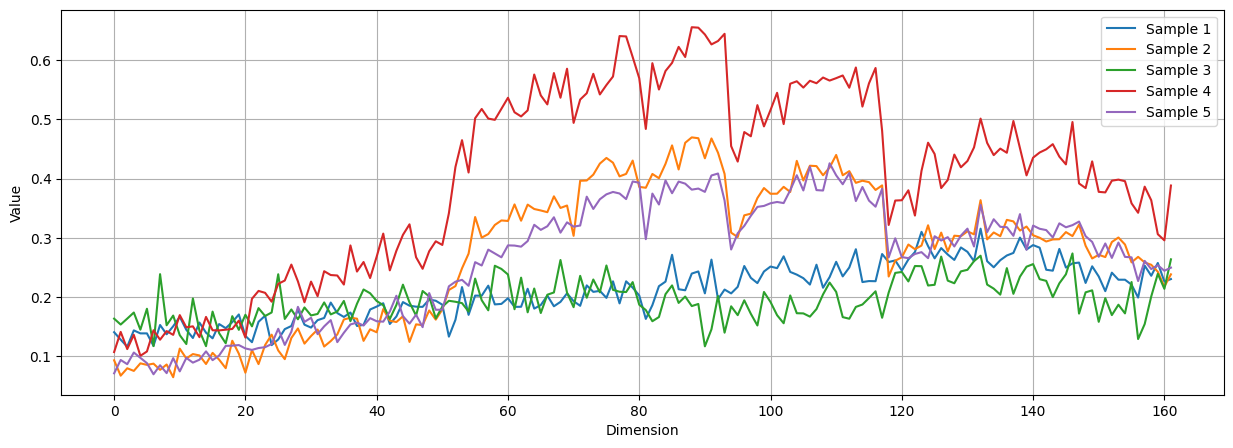

In [18]:
# Sampling
sample_idx = torch.randint(0, len(cond_tensor), (sample_batch_size,))
cond_sample = cond_tensor[sample_idx].to(device)
sampler = pc_sampler #@param ['Euler_Maruyama_sampler', 'pc_sampler', 'ode_sampler'] {'type': 'raw'}

## Generate samples using the specified sampler.
samples = sampler(model,
                cond_sample,
                use_condition,
                marginal_prob_std_fn,
                diffusion_coeff_fn,
                C,
                batch_size=sample_batch_size,
                num_steps = 1000,
                device=device)

plot_samples(samples, num_samples=5)  # Plot the first 5 samples


Euler Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]C:\Users\jiahuisheng\AppData\Local\Temp\ipykernel_28624\1240057907.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(sigma**t, device=t.device)
Euler Sampling: 100%|██████████| 1000/1000 [00:01<00:00, 572.65it/s]


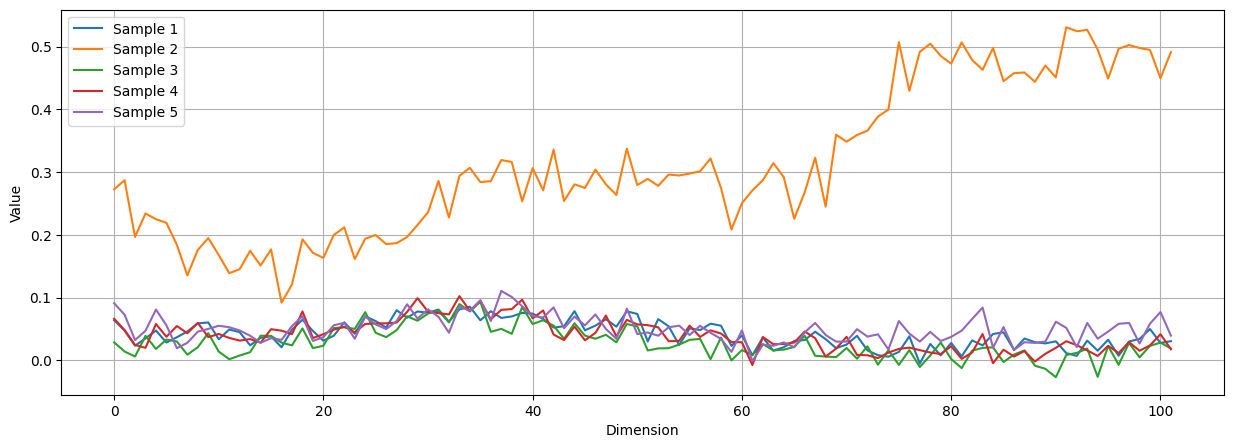

In [115]:
# Sampling
sample_idx = torch.randint(0, len(cond_tensor), (sample_batch_size,))
cond_sample = cond_tensor[sample_idx].to(device)
sampler = euler_sampler #@param ['Euler_Maruyama_sampler', 'pc_sampler', 'ode_sampler'] {'type': 'raw'}

## Generate samples using the specified sampler.
samples = sampler(model,
                cond_sample,
                use_condition,
                marginal_prob_std_fn,
                diffusion_coeff_fn,
                C,
                batch_size=sample_batch_size,
                num_steps = 1000,
                device=device)

plot_samples(samples, num_samples=5)  # Plot the first 5 samples


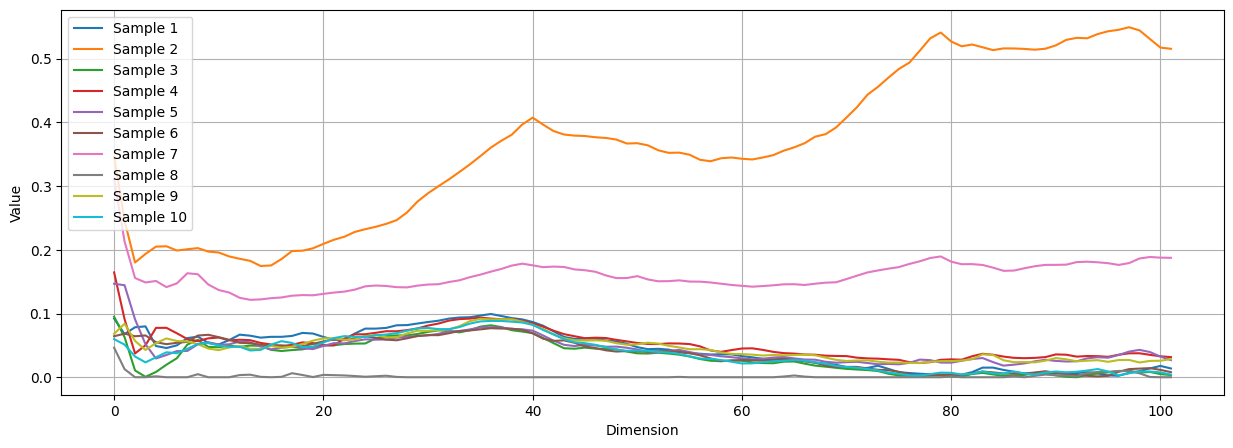

In [116]:
indices = torch.randint(0, x_tensor.shape[0], (10,))
plot_samples(x_tensor[indices], num_samples=10)

# Score Estimation

In [ ]:
# Score Estimation
perturbed_values = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.9]
# perturbed_values = [0.01, 0.05]
score_maps = []

for val in perturbed_values:
    t = torch.full((N*M,), fill_value=val, device=device)
    score = estimate_score(model, device, tensor_data, t, cond_tensor, use_condition, marginal_prob_std_fn, perturbed_num, eps=1e-5)
    score_magnitude = torch.norm(score, dim=1).view(data.shape[0], data.shape[1]).cpu().numpy()
    score_maps.append(score_magnitude)

    sio.savemat(f'./results/{dataset_name}_SAD_t{val:.3f}_{use_condition}_{inner_size}_{patch_size}.mat', {'SAD_result': score_magnitude})
    # sio.savemat(f'./results_for_t/{dataset_name}_SAD_t{val:.3f}.mat', {'SAD_result': score_magnitude})



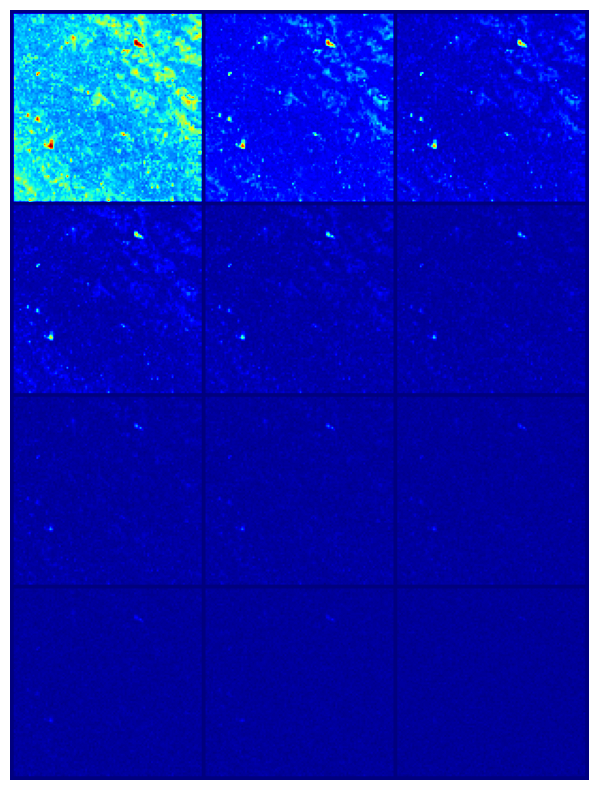

In [140]:
import torchvision.utils as vutils
score_maps_tensor = torch.stack([
    torch.from_numpy(sm).unsqueeze(0)  # (1, H, W)
    for sm in score_maps
])  # -> (B, 1, H, W)

grid = vutils.make_grid(score_maps_tensor, nrow=3, padding=2, normalize=True)

plt.figure(figsize=(10, 10))
plt.imshow(grid[0].cpu(), cmap='jet')
plt.axis('off')
plt.show()

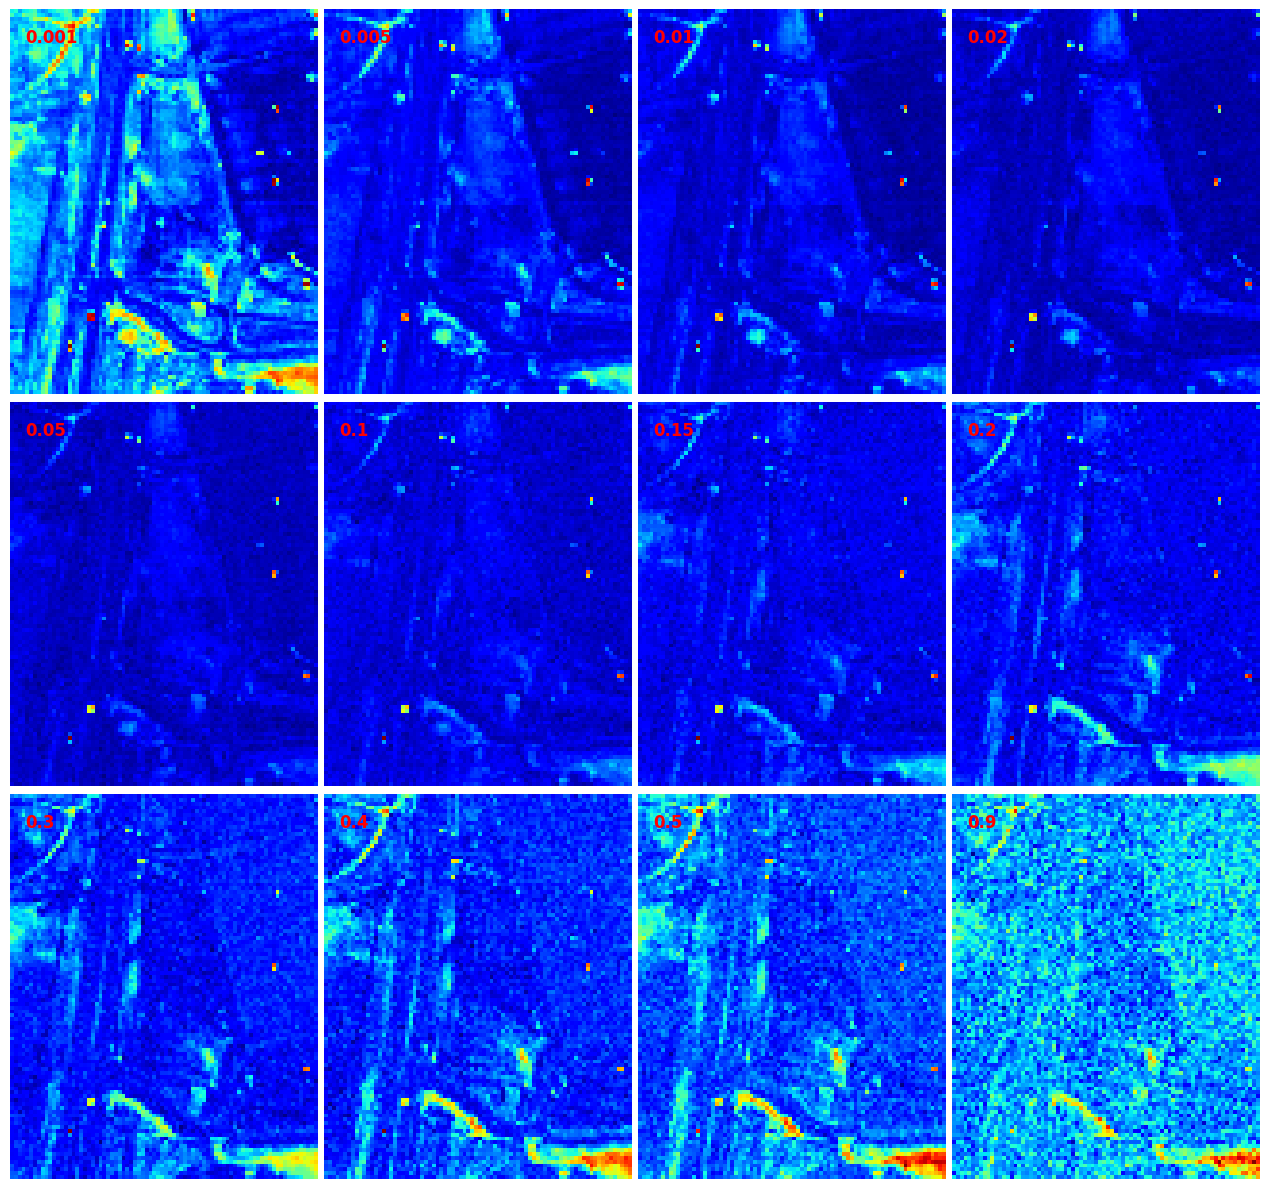

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# score_maps: list of numpy arrays, each [H, W]
nrow = 3
ncol = int(np.ceil(len(score_maps) / nrow))

fig, axs = plt.subplots(nrow, ncol, figsize=( 4* M/N * ncol, 4 * nrow))

for idx, sm in enumerate(score_maps):

    sm_norm = (sm - sm.min()) / (sm.max() - sm.min() + 1e-8)

    row, col = divmod(idx, ncol)
    ax = axs[row][col] if nrow > 1 else axs[col]
    im = ax.imshow(sm_norm, cmap='jet')
    ax.axis('off')

    label_text = f'{perturbed_values[idx]}'
    

    ax.text(0.05, 0.95, label_text, 
            ha='left', 
            va='top', 
            transform=ax.transAxes, 
            color='red',       
            fontsize=12,            
            fontweight='bold')      

for i in range(len(score_maps), nrow * ncol):
    row, col = divmod(i, ncol)
    ax = axs[row][col] if nrow > 1 else axs[col]
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(wspace=0.02, hspace=0.02)
plt.show()

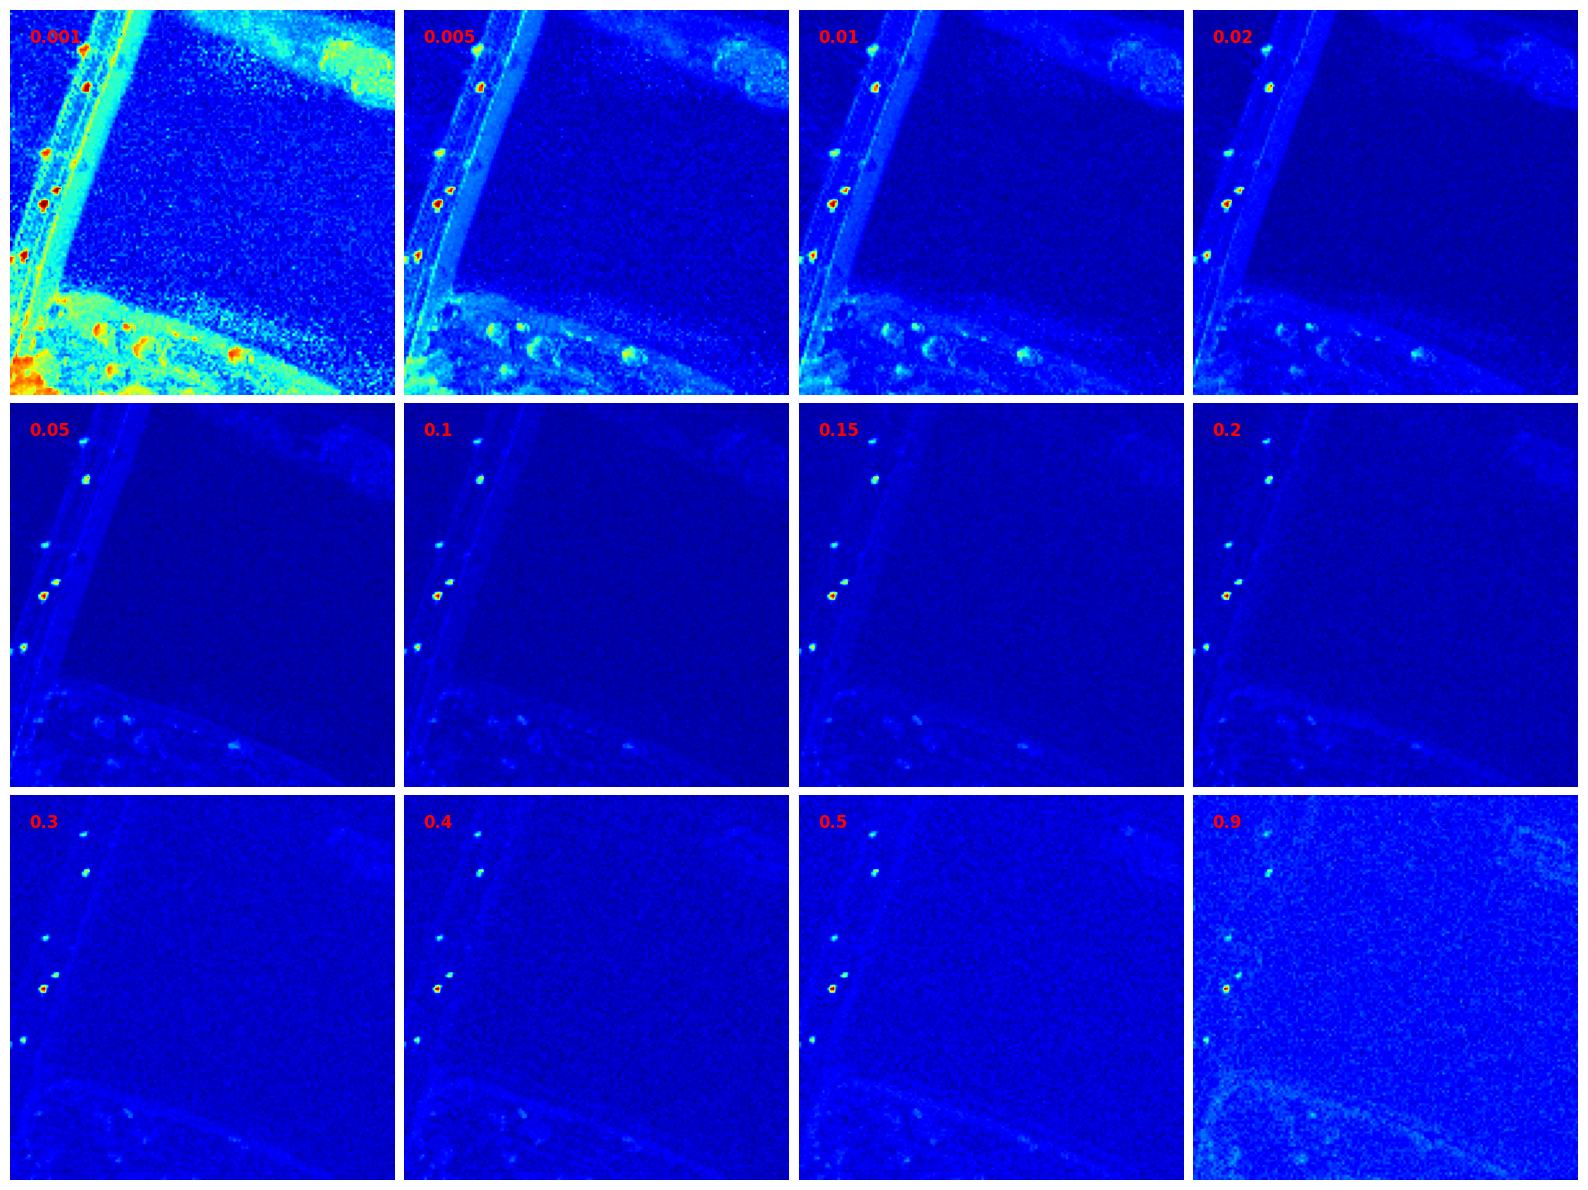

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# score_maps: list of numpy arrays, each [H, W]
nrow = 3
ncol = int(np.ceil(len(score_maps) / nrow))

fig, axs = plt.subplots(nrow, ncol, figsize=( 4* M/N * ncol, 4 * nrow))

for idx, sm in enumerate(score_maps):

    sm_norm = (sm - sm.min()) / (sm.max() - sm.min() + 1e-8)

    row, col = divmod(idx, ncol)
    ax = axs[row][col] if nrow > 1 else axs[col]
    im = ax.imshow(sm_norm, cmap='jet')
    ax.axis('off')

    label_text = f'{perturbed_values[idx]}'
    

    ax.text(0.05, 0.95, label_text, 
            ha='left', 
            va='top', 
            transform=ax.transAxes, 
            color='red',       
            fontsize=12,            
            fontweight='bold')      

for i in range(len(score_maps), nrow * ncol):
    row, col = divmod(i, ncol)
    ax = axs[row][col] if nrow > 1 else axs[col]
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(wspace=0.02, hspace=0.02)
plt.show()

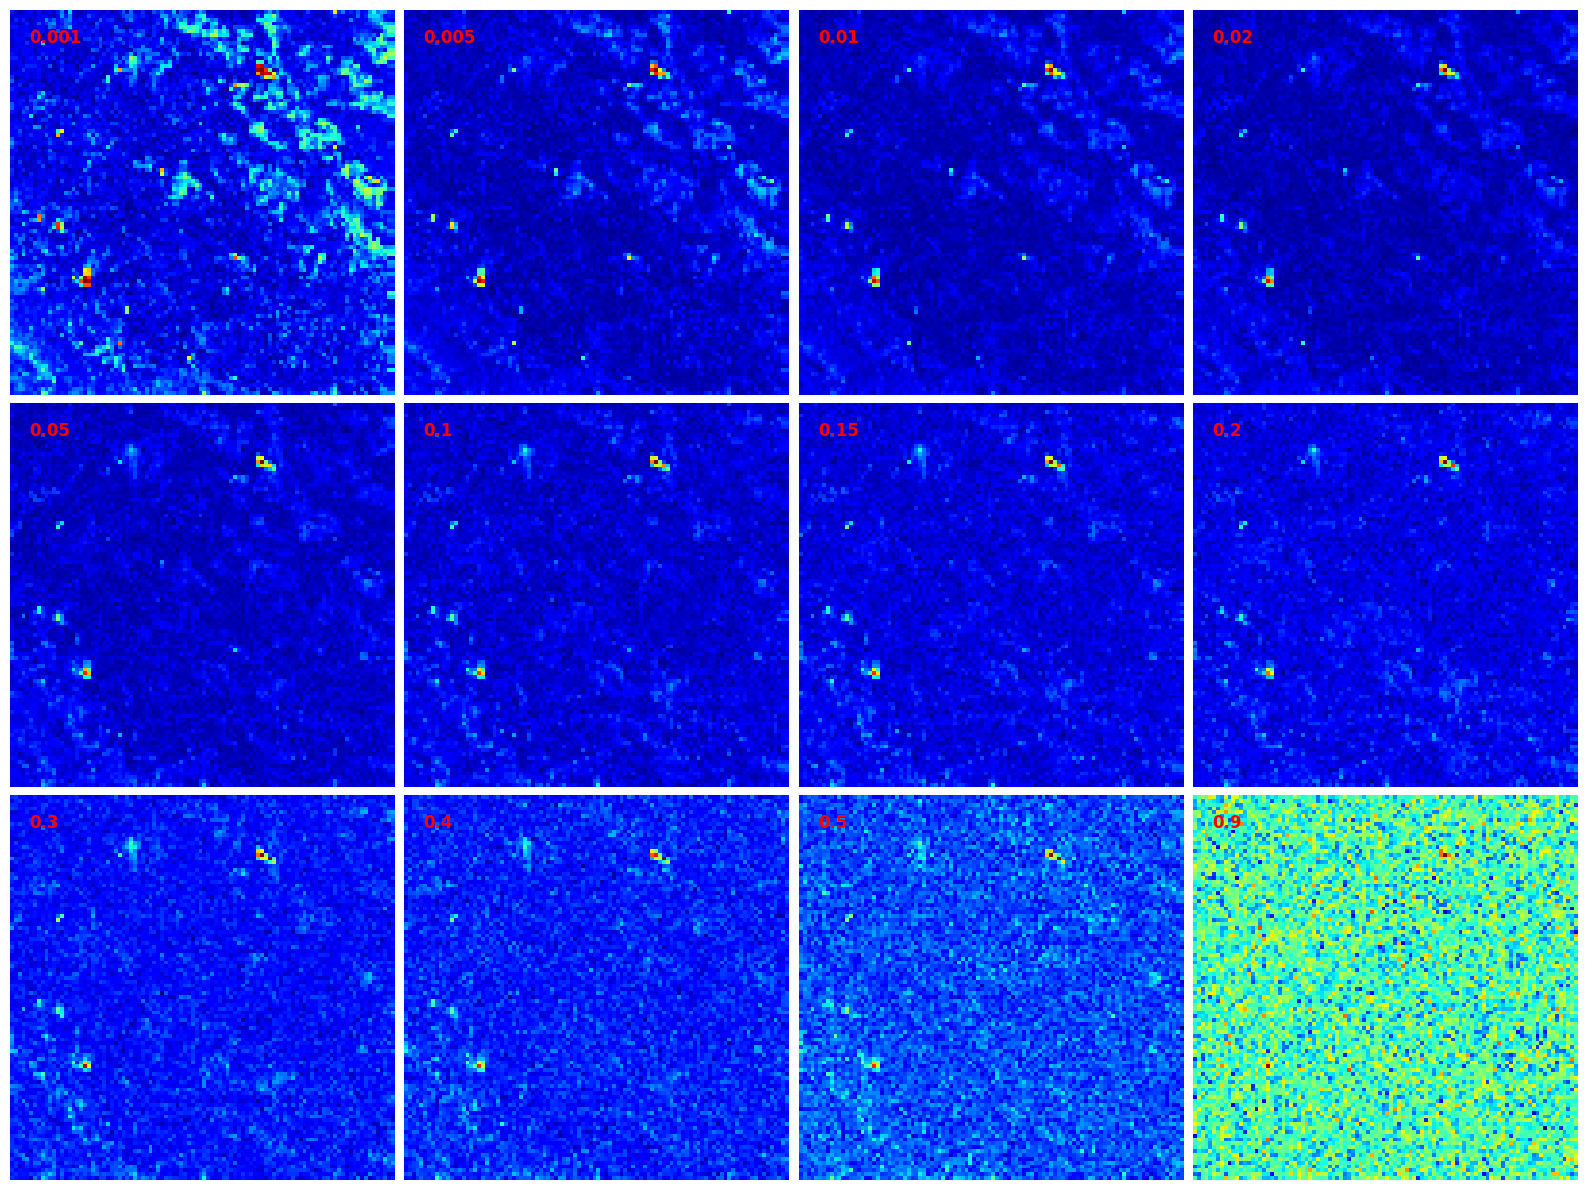

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# score_maps: list of numpy arrays, each [H, W]
nrow = 3
ncol = int(np.ceil(len(score_maps) / nrow))

fig, axs = plt.subplots(nrow, ncol, figsize=( 4* M/N * ncol, 4 * nrow))

for idx, sm in enumerate(score_maps):

    sm_norm = (sm - sm.min()) / (sm.max() - sm.min() + 1e-8)

    row, col = divmod(idx, ncol)
    ax = axs[row][col] if nrow > 1 else axs[col]
    im = ax.imshow(sm_norm, cmap='jet')
    ax.axis('off')

    label_text = f'{perturbed_values[idx]}'
    

    ax.text(0.05, 0.95, label_text, 
            ha='left', 
            va='top', 
            transform=ax.transAxes, 
            color='red',       
            fontsize=12,            
            fontweight='bold')      

for i in range(len(score_maps), nrow * ncol):
    row, col = divmod(i, ncol)
    ax = axs[row][col] if nrow > 1 else axs[col]
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(wspace=0.02, hspace=0.02)
plt.show()

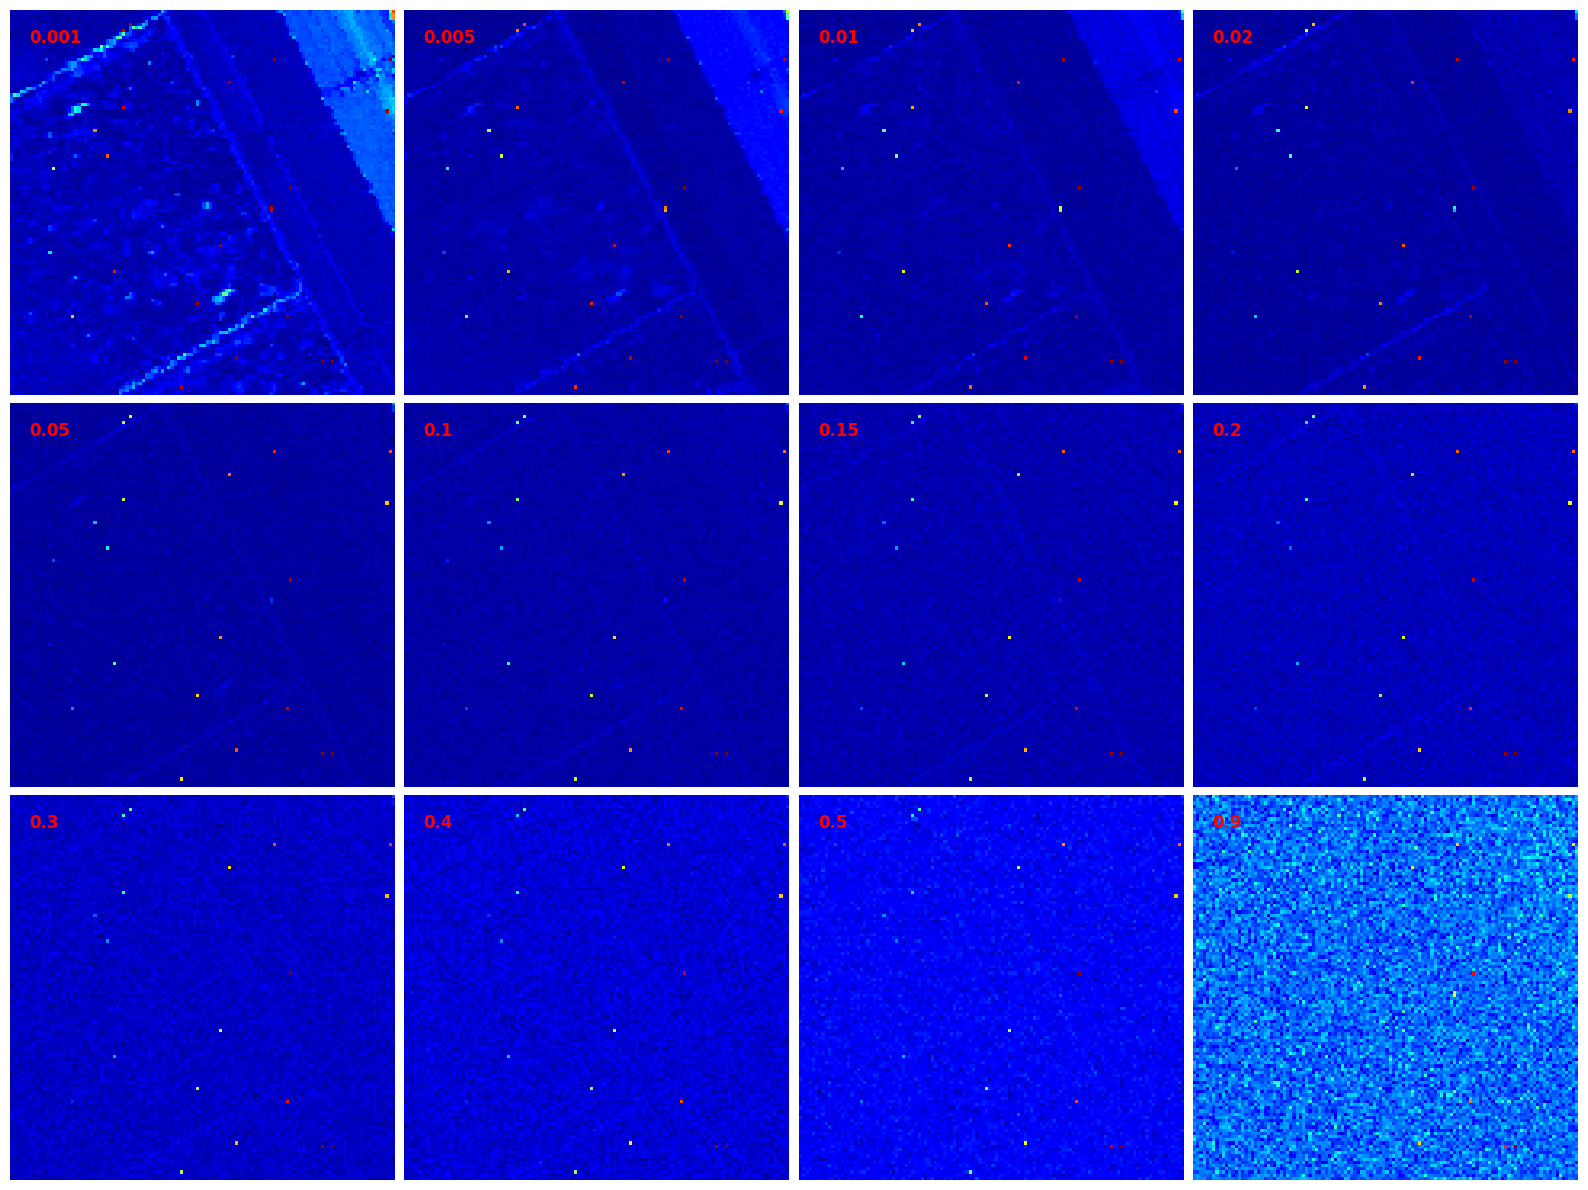

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# score_maps: list of numpy arrays, each [H, W]
nrow = 3
ncol = int(np.ceil(len(score_maps) / nrow))

fig, axs = plt.subplots(nrow, ncol, figsize=( 4* M/N * ncol, 4 * nrow))

for idx, sm in enumerate(score_maps):

    sm_norm = (sm - sm.min()) / (sm.max() - sm.min() + 1e-8)

    row, col = divmod(idx, ncol)
    ax = axs[row][col] if nrow > 1 else axs[col]
    im = ax.imshow(sm_norm, cmap='jet')
    ax.axis('off')

    label_text = f'{perturbed_values[idx]}'
    

    ax.text(0.05, 0.95, label_text, 
            ha='left', 
            va='top', 
            transform=ax.transAxes, 
            color='red',       
            fontsize=12,            
            fontweight='bold')      

for i in range(len(score_maps), nrow * ncol):
    row, col = divmod(i, ncol)
    ax = axs[row][col] if nrow > 1 else axs[col]
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(wspace=0.02, hspace=0.02)
plt.show()